In [2]:
import pandas as pd 
import numpy as numpy
import seaborn as sns


In [3]:
df = pd.read_csv(r"C:\Users\Sushant\Downloads\spam.csv", encoding = 'latin-1')
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
997,ham,Not a lot has happened here. Feels very quiet....,NaN,NaN,NaN
3050,ham,Awesome question with a cute answer: Someone a...,NaN,NaN,NaN
5219,ham,Pls she needs to dat slowly or she will vomit ...,NaN,NaN,NaN
5428,ham,You didnt complete your gist oh.,NaN,NaN,NaN
4513,ham,"Sure, whenever you show the fuck up &gt;:(",NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis = 1, inplace = True)
df.rename(columns= {"v1":"target", "v2": "mail"}, inplace = True)

In [6]:
df.duplicated().sum()
df = df.drop_duplicates(keep = 'first')
df.duplicated().sum()

np.int64(0)

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])
df


,target,mail
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [8]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

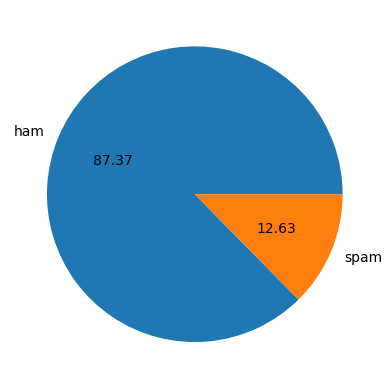

In [9]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

Data is Imbalanced

In [10]:
!pip install nltk
import nltk
nltk.download('punkt_tab')

Defaulting to user installation because normal site-packages is not writeable


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sushant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [11]:
# num of characters
df['num_characters'] = df['mail'].apply(len)

In [12]:
df.head()

,target,mail,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [13]:
#num of words
df['num_words'] = df['mail'].apply(lambda X: nltk.word_tokenize(X)).apply(len)
df.head()

,target,mail,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [14]:
df['num_sentences'] = df['mail'].apply(lambda X: nltk.sent_tokenize(X)).apply(len)
df.head()

,target,mail,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [15]:
df.describe()

,target,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [16]:
#ham
df[df['target']==0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [17]:
#spam
df[df['target']==1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

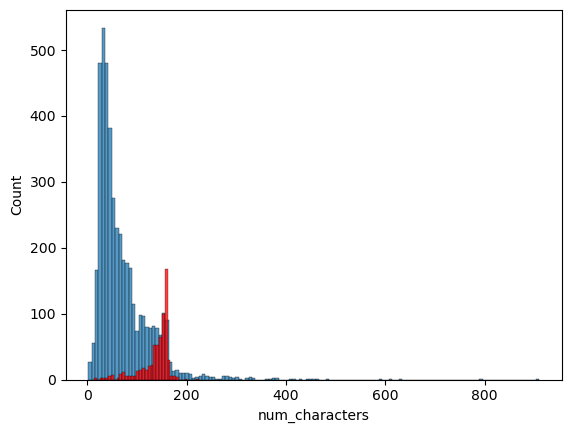

In [18]:
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

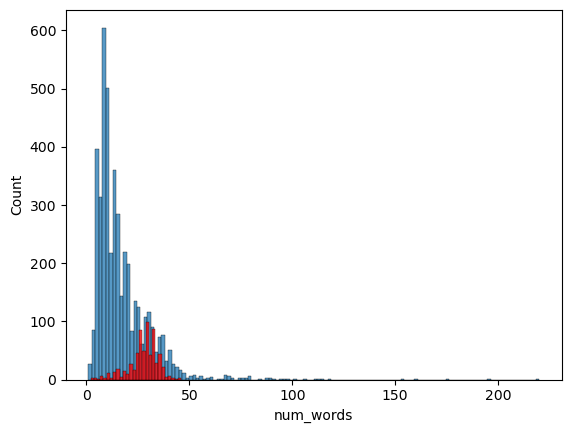

In [19]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

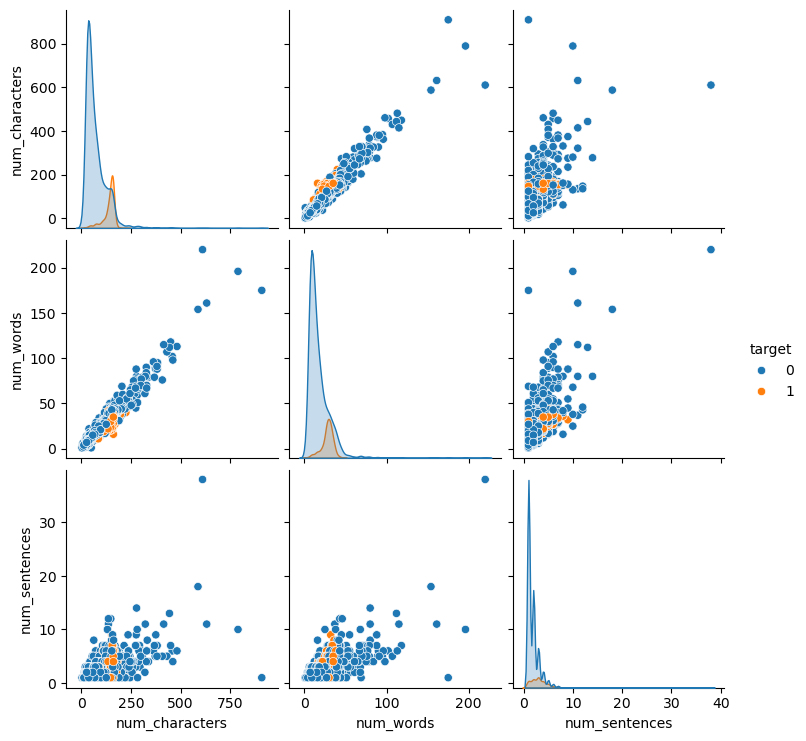

In [20]:
sns.pairplot(df,hue='target')

<Axes: >

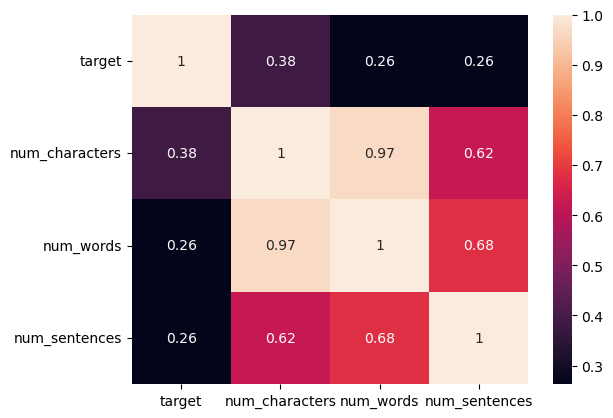

In [21]:
sns.heatmap(df.corr(numeric_only=True), annot = True)

3. Data Preprocessing -

Lowercase,
Tokenization,
Removing special characters,
Removing stop words and punctuation,
Stemming

In [22]:
import string 
import re

from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sushant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y.copy()
    y.clear()

    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)





In [24]:
preprocess("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'im gon na home soon dont want talk stuff anymor tonight k ive cri enough today'

In [25]:
df['transformed_text'] = df['mail'].apply(preprocess)

In [26]:
!pip install wordcloud -q
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [27]:
spam_wc = wc.generate(df[df['target'] ==1]['transformed_text'].str.cat(sep=" "))

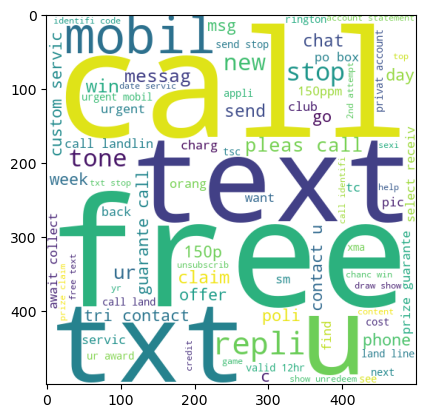

In [28]:
plt.imshow(spam_wc)

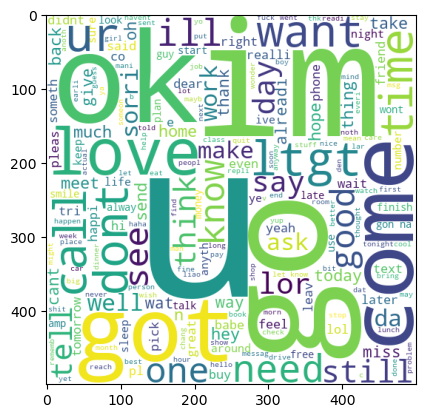

In [29]:
ham_wc = wc.generate(df[df['target'] ==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

In [30]:
spam_corpus=[]
spam_list = df[df['target']==1]['transformed_text'].tolist()
for msg in spam_list:
    for word in msg.split():
        spam_corpus.append(word)


In [31]:
len(spam_corpus)

10813

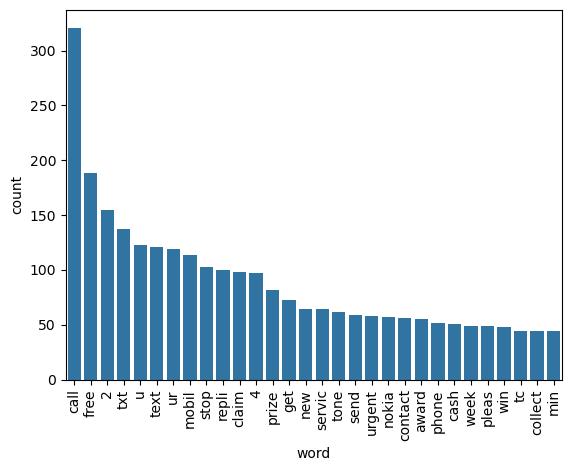

In [32]:
from collections import Counter


df_top30 = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word','count'])
sns.barplot(data=df_top30, x='word', y='count')
plt.xticks(rotation = 'vertical')
plt.show()

In [33]:
ham_corpus=[]
ham_list = df[df['target']==0]['transformed_text'].tolist()
for msg in ham_list:
    for word in msg.split():
        ham_corpus.append(word)

len(ham_corpus)

36813

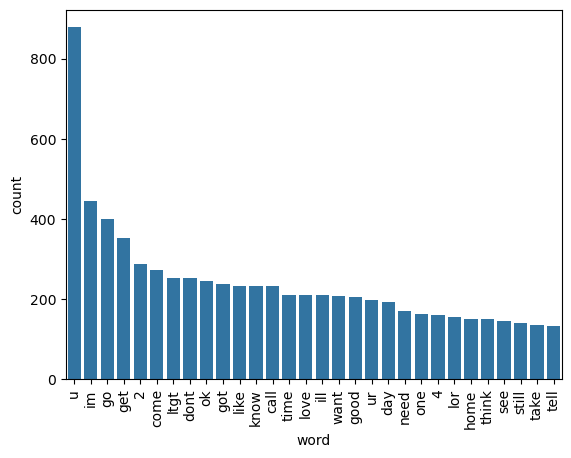

In [34]:
from collections import Counter


df_top30 = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word','count'])
sns.barplot(data=df_top30, x='word', y='count')
plt.xticks(rotation = 'vertical')
plt.show()

# 4. Model Building

In [35]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [36]:
#X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [37]:
X.shape

(5169, 7979)

In [38]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [39]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [40]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))


0.8762088974854932
[[790 106]
 [ 22 116]]
0.5225225225225225


In [41]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9564796905222437
[[896   0]
 [ 45  93]]
1.0


In [42]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9709864603481625
[[894   2]
 [ 28 110]]
0.9821428571428571


In [43]:
# tfidf ---> MNB

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost -q
from xgboost import XGBClassifier

In [45]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [46]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [47]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [48]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.971953578336557, 0.9739130434782609)

In [49]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.971953578336557
Precision -  0.9739130434782609
For  KN
Accuracy -  0.8965183752417795
Precision -  1.0
For  NB
Accuracy -  0.9564796905222437
Precision -  1.0
For  DT
Accuracy -  0.941972920696325
Precision -  0.875
For  LR
Accuracy -  0.9526112185686654
Precision -  0.9405940594059405
For  RF
Accuracy -  0.9709864603481625
Precision -  0.990909090909091
For  AdaBoost
Accuracy -  0.9332688588007737
Precision -  0.8876404494382022
For  BgC
Accuracy -  0.9622823984526112
Precision -  0.889763779527559
For  ETC
Accuracy -  0.9709864603481625
Precision -  0.9736842105263158
For  GBDT
Accuracy -  0.9584139264990329
Precision -  0.9357798165137615
For  xgb
Accuracy -  0.9709864603481625
Precision -  0.9426229508196722


In [ ]:
results = pd.DataFrame({
    'Model': list(clfs.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

results.sort_values('Precision', ascending=False, inplace=True)
results

TypeError: '<' not supported between instances of 'function' and 'function'